# Análisis Sector Biotech/Pharma 2009-2026

**Autor:** Fernando  
**Período:** 2009 - 2026  
**Dataset:** 1.208 operaciones de inversión global

---

## Objetivo

Explorar patrones de inversión en el sector biotecnológico y farmacéutico,
identificar los principales actores del mercado, y generar una estimación
predictiva para el segundo semestre de 2026.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Fernando\OneDrive\Documentos\proyecto data analytics\datos\biotech_funding.csv")

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Período: {df['year'].min()} - {df['year'].max()}")
df.head()

## Tarea 1 — Auditoría de datos

In [3]:
# Valores nulos
print("=== VALORES NULOS ===")
print(df.isnull().sum())
print()

# Duplicados
print("=== DUPLICADOS ===")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"Deal IDs duplicados: {df['deal_id'].duplicated().sum()}")

=== VALORES NULOS ===
deal_id                  0
date                     0
year                     0
deal_type                0
acquirer_or_investors    0
target_or_company        0
value_usd_bn             0
description              0
is_megadeal              0
is_real_headline         0
dtype: int64

=== DUPLICADOS ===
Filas duplicadas: 0
Deal IDs duplicados: 0


## Tarea 2 — Serie Temporal

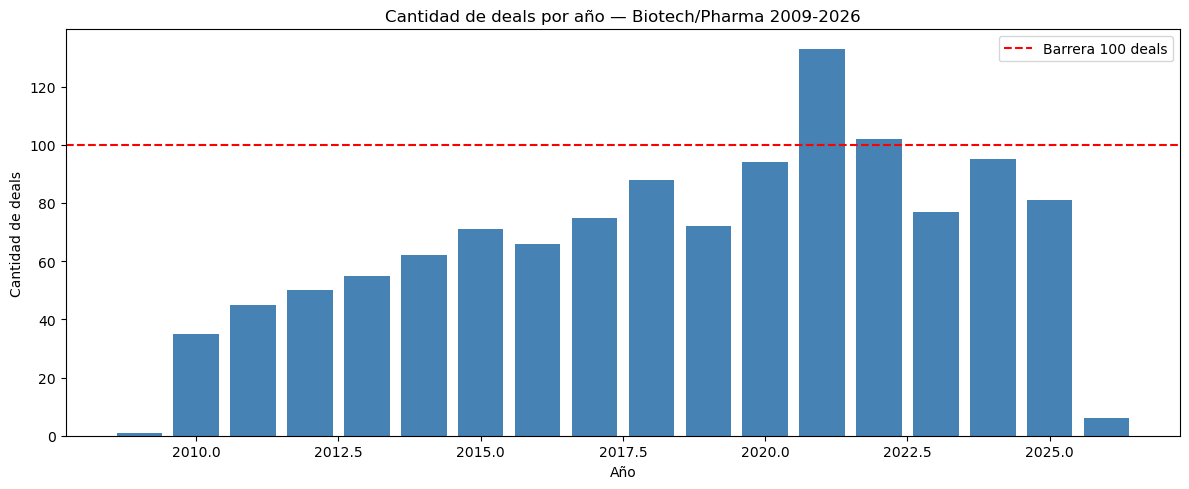

In [4]:
por_año = df.groupby("year").agg(
    cantidad_deals=("deal_id", "count"),
    capital_usd_bn=("value_usd_bn", "sum")
).reset_index()

# Gráfico deals por año
plt.figure(figsize=(12, 5))
plt.bar(por_año["year"], por_año["cantidad_deals"], color="steelblue")
plt.axhline(y=100, color="red", linestyle="--", label="Barrera 100 deals")
plt.title("Cantidad de deals por año — Biotech/Pharma 2009-2026")
plt.xlabel("Año")
plt.ylabel("Cantidad de deals")
plt.legend()
plt.tight_layout()
plt.show()

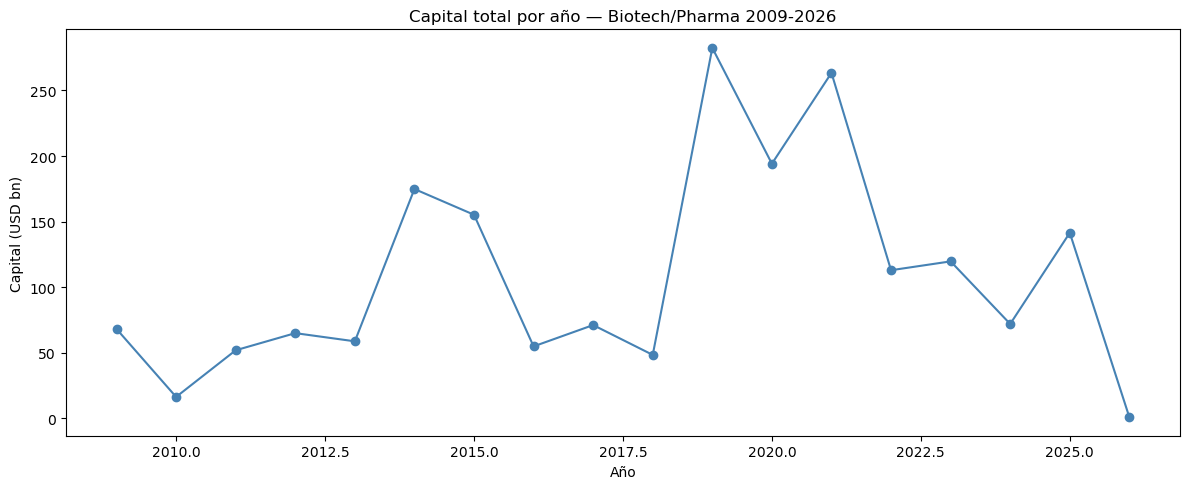

In [5]:
# Gráfico capital por año
plt.figure(figsize=(12, 5))
plt.plot(por_año["year"], por_año["capital_usd_bn"], color="steelblue", marker="o")
plt.title("Capital total por año — Biotech/Pharma 2009-2026")
plt.xlabel("Año")
plt.ylabel("Capital (USD bn)")
plt.tight_layout()
plt.show()

## Tarea 3 — Ranking de Inversores

In [6]:
capital = df.groupby("acquirer_or_investors")["value_usd_bn"].sum()
deals = df.groupby("acquirer_or_investors")["deal_id"].count()

ranking = pd.DataFrame({
    "capital_usd_bn": capital,
    "cantidad_deals": deals
})

ranking["promedio_por_deal"] = ranking["capital_usd_bn"] / ranking["cantidad_deals"]
ranking = ranking.sort_values("capital_usd_bn", ascending=False)

ranking

,capital_usd_bn,cantidad_deals,promedio_por_deal
acquirer_or_investors,,,
AbbVie,184.730,16,11.545625
BMS,182.165,12,15.180417
Sanofi,180.010,22,8.182273
Roche,143.381,16,8.961313
AstraZeneca,133.322,18,7.406778
Eli Lilly,125.909,9,13.989889
Pfizer,120.158,14,8.582714
Amgen,109.308,15,7.287200
J&J,83.367,15,5.557800


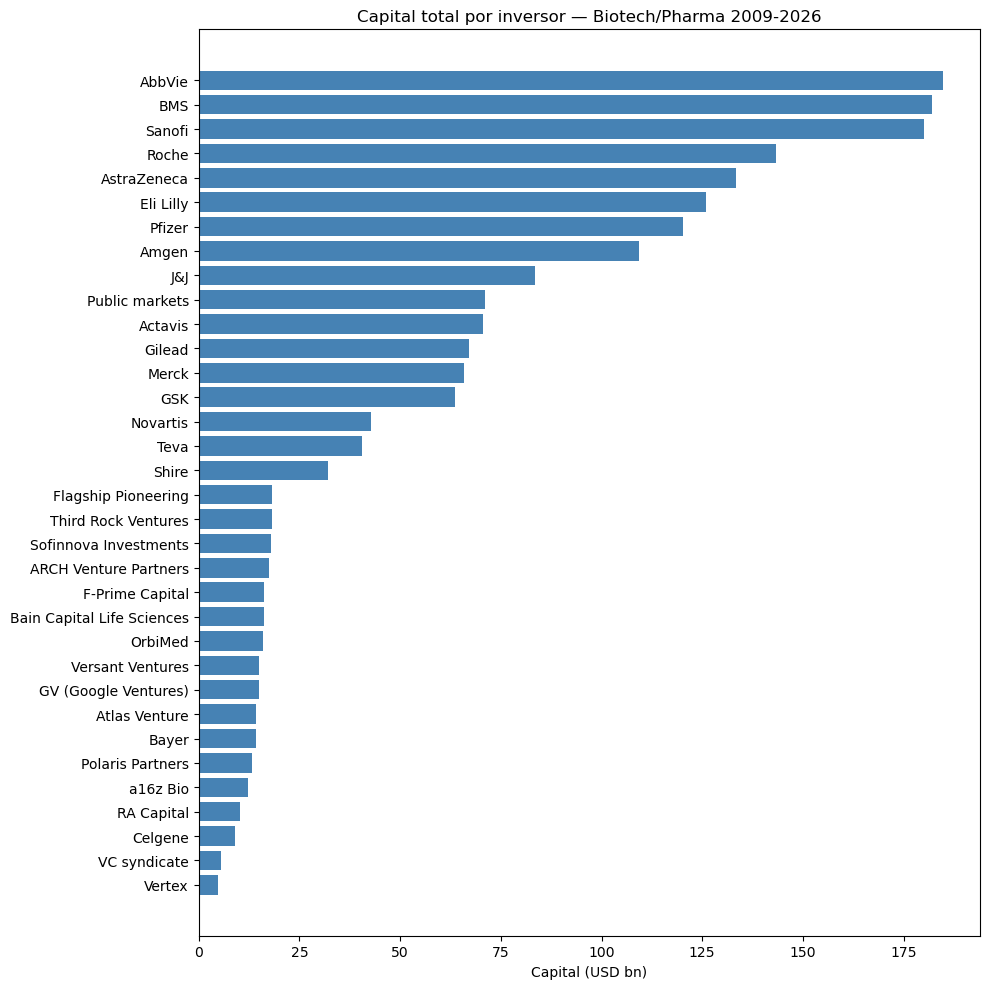

In [7]:
capital_ordenado = df.groupby("acquirer_or_investors")["value_usd_bn"].sum().sort_values()

plt.figure(figsize=(10, 10))
plt.barh(capital_ordenado.index, capital_ordenado.values, color="steelblue")
plt.title("Capital total por inversor — Biotech/Pharma 2009-2026")
plt.xlabel("Capital (USD bn)")
plt.tight_layout()
plt.show()

## Tarea 4 — Modelo Predictivo 2026

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Sacar 2026 porque está incompleto
datos = por_año[por_año["year"] < 2026]

# Regresión lineal
X = datos[["year"]]
y_deals = datos["cantidad_deals"]
modelo = LinearRegression()
modelo.fit(X, y_deals)
pred_regresion = modelo.predict([[2026]])[0]

# Promedio últimos 3 años
ultimos_3 = datos[datos["year"] >= 2023]
pred_deals = ultimos_3["cantidad_deals"].mean()
pred_capital = ultimos_3["capital_usd_bn"].mean()

print(f"Regresión lineal (sesgada por pandemia): {pred_regresion:.0f} deals")
print(f"Promedio 2023-2025 (método honesto):     {pred_deals:.0f} deals")
print(f"Capital estimado 2026:                   ${pred_capital:.1f}bn")

Regresión lineal (sesgada por pandemia): 114 deals
Promedio 2023-2025 (método honesto):     84 deals
Capital estimado 2026:                   $110.9bn


C:\Users\Fernando\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Conclusiones

- **Dataset limpio:** sin nulos, sin duplicados
- **Pico histórico:** 2021 con 133 deals impulsado por pandemia
- **Mayor capital:** 2019 con $282bn (6 megadeals)
- **Mercado concentrado:** top 5 inversores controlan el 42% del capital
- **Dos mundos:** Pharma mueve 8x más capital que VC
- **Caso extremo:** Actavis compró Allergan por $70.5bn en un solo deal (2014)
- **Estimación 2026:** ~84 deals y ~$111bn de capital